<a href="https://colab.research.google.com/github/TanviDeore/ASL_Recognition_Grp14/blob/main/ASL_OpticalFlow_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASL Recognition — Optical Flow Feature Extraction

This notebook picks up where `ASL_Colab_Setup.ipynb` leaves off.

**Pipeline implemented here:**
1. Re-download preprocessed frames from Box
2. Load `nslt_100.json` to map each video → class index + train/val/test split
3. Compute Farnebäck dense optical flow between consecutive frames
4. Visualize sample flows (HSV-encoded) for the report
5. Extract per-video features (HOOF + magnitude histogram + stats)
6. Save `features.npy`, `labels.npy`, `splits.json` for model training

## 0. Setup — Install dependencies + fetch metadata + download frames

In [1]:
!pip install -q opencv-python numpy matplotlib tqdm requests

In [3]:
# Pull metadata file from the repo
import os, urllib.request

url = 'https://raw.githubusercontent.com/TanviDeore/ASL_Recognition_Grp14/main/data/nslt_100.json'
urllib.request.urlretrieve(url, 'nslt_100.json')

assert os.path.exists('nslt_100.json') and os.path.getsize('nslt_100.json') > 0, 'Download failed'
print(f'Downloaded nslt_100.json — {os.path.getsize("nslt_100.json")/1024:.1f} KB')

Downloaded nslt_100.json — 104.6 KB


In [4]:
# Download preprocessed frames from Box.
# Skips the download if frames are already present (re-run safe).
import os, requests, zipfile
from tqdm import tqdm

def download_data():
    url = 'https://utdallas.box.com/shared/static/5ry2jpk80fxvdq9xet51q65o3sd6bx0v.zip'
    output_zip = '/content/asl_frames.zip'
    extract_to = 'data/frames'

    if os.path.exists(extract_to) and len(os.listdir(extract_to)) > 0:
        print(f'Frames already present at {extract_to} ({len(os.listdir(extract_to))} folders) — skipping download.')
        return

    os.makedirs('data', exist_ok=True)
    print('Downloading dataset from Box...')
    response = requests.get(url, stream=True)
    response.raise_for_status()
    total_size = int(response.headers.get('content-length', 0))
    with open(output_zip, 'wb') as f, tqdm(
        total=total_size, unit='iB', unit_scale=True, unit_divisor=1024
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            bar.update(f.write(chunk))

    print('\nExtracting frames...')
    with zipfile.ZipFile(output_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    os.remove(output_zip)
    print(f'Done. {len(os.listdir(extract_to))} folders ready in {extract_to}')

download_data()

1.57GiB [00:23, 73.0MiB/s]



Extracting frames...
Done. 1013 folders ready in data/frames


## 1. Build the work list

`nslt_100.json` has 2038 video entries, but only ~1013 folders were extracted (the rest are listed in `missing.txt` from the WLASL source). We process only the videos we actually have frames for.

In [5]:
import json
from collections import Counter

with open('nslt_100.json') as f:
    meta = json.load(f)

frames_root = 'data/frames'
available_video_ids = set(os.listdir(frames_root))

work_list = []
for vid, info in meta.items():
    if vid not in available_video_ids:
        continue
    work_list.append({
        'video_id': vid,
        'class_idx': info['action'][0],
        'subset': info.get('subset', 'unknown'),
    })

print(f'Entries in nslt_100.json: {len(meta)}')
print(f'Folders available in data/frames: {len(available_video_ids)}')
print(f'Videos to process: {len(work_list)}')
print(f'Subset distribution: {dict(Counter(w["subset"] for w in work_list))}')
print(f'Number of unique classes: {len(set(w["class_idx"] for w in work_list))}')

Entries in nslt_100.json: 2038
Folders available in data/frames: 1013
Videos to process: 1013
Subset distribution: {'val': 165, 'train': 748, 'test': 100}
Number of unique classes: 100


## 2. Step 4 — Farnebäck Dense Optical Flow

**Why dense optical flow?** It estimates a motion vector `(dx, dy)` for *every pixel* between two consecutive frames. For ASL, this captures the entire hand-and-arm motion field — not just sparse keypoints — which is what we want to classify gestures with.

**Why Farnebäck specifically?** It's the OpenCV built-in, runs on CPU at ~30 FPS, and is the canonical choice for classical optical-flow pipelines. RAFT (deep learning) would be more accurate but needs a GPU and adds dependencies — overkill for a feature pipeline that already has thousands of frame pairs.

**Why we resize to 160×120 first:** raw frames are larger; Farnebäck cost scales with pixel count. 160×120 keeps gesture-scale motion intact and runs ~6x faster than full-res. This is the standard cheat for HOOF-based recognition.

In [6]:
import cv2
import numpy as np

FLOW_SIZE = (160, 120)  # (width, height) — what we resize each frame to before computing flow

def compute_flow(prev_gray, next_gray):
    """Farnebäck dense optical flow. Returns (H, W, 2) array of (dx, dy) per pixel."""
    return cv2.calcOpticalFlowFarneback(
        prev_gray, next_gray, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0,
    )

def load_video_frames(video_dir):
    """Load all .jpg frames in a folder, sorted by filename."""
    files = sorted(f for f in os.listdir(video_dir) if f.endswith('.jpg'))
    frames = []
    for fn in files:
        img = cv2.imread(os.path.join(video_dir, fn))
        if img is not None:
            frames.append(img)
    return frames

def video_flows(video_dir):
    """For a video folder, return list of flow arrays — one per consecutive frame pair."""
    frames = load_video_frames(video_dir)
    if len(frames) < 2:
        return []
    flows = []
    prev_gray = cv2.cvtColor(cv2.resize(frames[0], FLOW_SIZE), cv2.COLOR_BGR2GRAY)
    for i in range(1, len(frames)):
        next_gray = cv2.cvtColor(cv2.resize(frames[i], FLOW_SIZE), cv2.COLOR_BGR2GRAY)
        flows.append(compute_flow(prev_gray, next_gray))
        prev_gray = next_gray
    return flows

# Quick sanity check on one video
sample_dir = os.path.join(frames_root, work_list[0]['video_id'])
flows = video_flows(sample_dir)
print(f'Video {work_list[0]["video_id"]}: {len(flows)} flow pairs, each of shape {flows[0].shape}')

Video 69422: 29 flow pairs, each of shape (120, 160, 2)


## 3. Step 5 — Visualize Optical Flow

We encode flow as an HSV image and convert to BGR:
- **Hue** = direction of motion (angle)
- **Saturation** = constant 255
- **Value** = magnitude of motion (normalized)

Result: stationary regions are black, moving regions glow with a color that indicates direction.

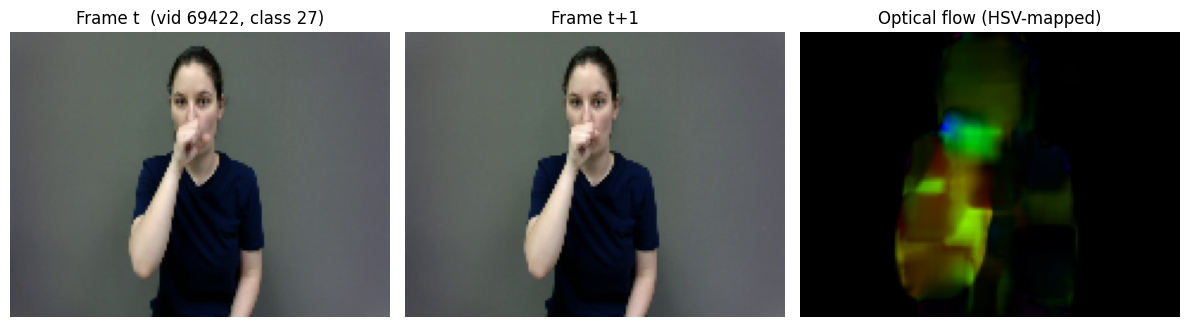

Saved visualizations/flow_class27_vid69422.png


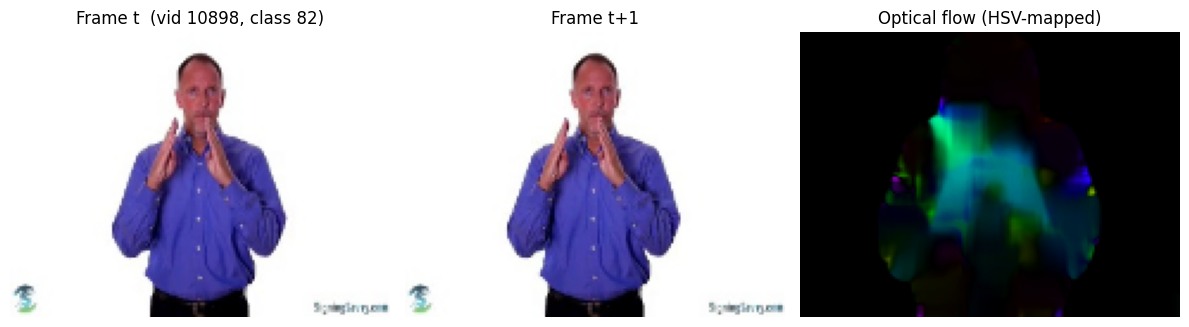

Saved visualizations/flow_class82_vid10898.png


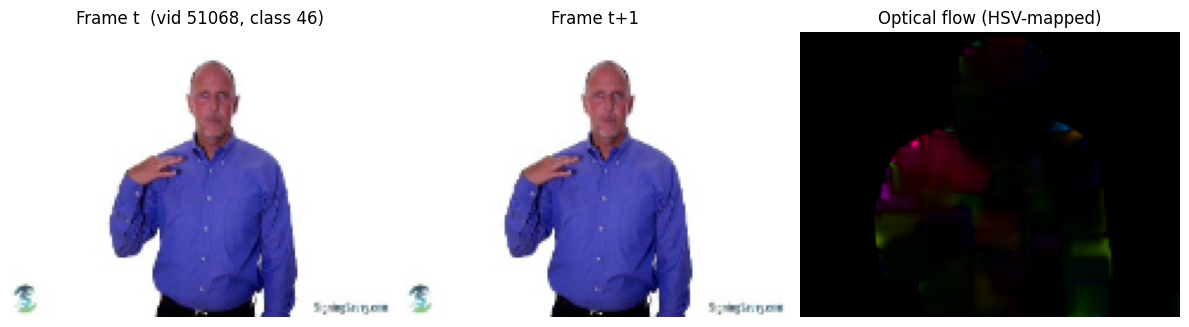

Saved visualizations/flow_class46_vid51068.png


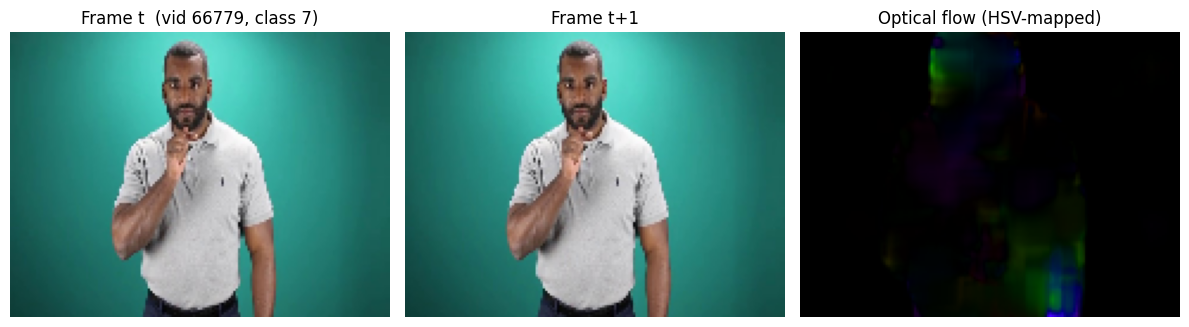

Saved visualizations/flow_class07_vid66779.png


In [7]:
import matplotlib.pyplot as plt

def flow_to_rgb(flow):
    h, w = flow.shape[:2]
    hsv = np.zeros((h, w, 3), dtype=np.uint8)
    hsv[..., 1] = 255
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = (ang * 180 / np.pi / 2).astype(np.uint8)
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

os.makedirs('visualizations', exist_ok=True)

# Pick one video each from 4 different classes
samples, seen = [], set()
for w in work_list:
    if w['class_idx'] not in seen:
        samples.append(w)
        seen.add(w['class_idx'])
    if len(samples) == 4:
        break

for sv in samples:
    video_dir = os.path.join(frames_root, sv['video_id'])
    frames = load_video_frames(video_dir)
    if len(frames) < 2:
        continue
    mid = len(frames) // 2
    f1 = cv2.resize(frames[mid - 1], FLOW_SIZE)
    f2 = cv2.resize(frames[mid], FLOW_SIZE)
    flow = compute_flow(
        cv2.cvtColor(f1, cv2.COLOR_BGR2GRAY),
        cv2.cvtColor(f2, cv2.COLOR_BGR2GRAY),
    )
    flow_rgb = flow_to_rgb(flow)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    axes[0].imshow(cv2.cvtColor(f1, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Frame t  (vid {sv["video_id"]}, class {sv["class_idx"]})')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(f2, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Frame t+1')
    axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(flow_rgb, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Optical flow (HSV-mapped)')
    axes[2].axis('off')
    save_path = f'visualizations/flow_class{sv["class_idx"]:02d}_vid{sv["video_id"]}.png'
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=130)
    plt.show()
    print(f'Saved {save_path}')

## 4. Step 6 — Feature Extraction (HOOF + Magnitude Histogram + Stats)

We turn each flow field (160 × 120 × 2 = 38,400 numbers) into a fixed-size feature vector.

**HOOF (Histogram of Oriented Optical Flow)** — 8 angle bins, each pixel contributes its magnitude as the weight. Captures *which directions* the motion is pointing in this frame pair. Standard for optical-flow gesture recognition.

**Magnitude histogram** — 8 bins. Captures *how much* motion there is (slow vs fast gestures).

**Stats** — mean, std, max of magnitude + mean angle. Cheap global summary.

Total = **20 dims per frame pair**. We then **average across all pairs** in a video to get a single 20-dim vector per video. Averaging is robust to videos of slightly different lengths and is the cleanest input for an SVM.

In [8]:
ANGLE_BINS = 8
MAG_BINS = 8
FEATURE_DIM = ANGLE_BINS + MAG_BINS + 4  # 20

def per_pair_features(flow):
    """Convert one flow field (H, W, 2) into a 20-dim feature vector."""
    fx, fy = flow[..., 0], flow[..., 1]
    mag, ang = cv2.cartToPolar(fx, fy)  # ang in radians [0, 2π)
    mag_flat = mag.ravel()
    ang_flat = ang.ravel()

    # HOOF — angle histogram weighted by magnitude, then L1-normalized
    hoof, _ = np.histogram(ang_flat, bins=ANGLE_BINS, range=(0, 2 * np.pi), weights=mag_flat)
    if hoof.sum() > 0:
        hoof = hoof / hoof.sum()

    # Magnitude histogram (clip top 1% to suppress outliers from flow errors)
    mag_clipped = np.clip(mag_flat, 0, np.percentile(mag_flat, 99) + 1e-6)
    mhist, _ = np.histogram(mag_clipped, bins=MAG_BINS)
    if mhist.sum() > 0:
        mhist = mhist / mhist.sum()

    stats = np.array([mag.mean(), mag.std(), mag.max(), ang.mean()])
    return np.concatenate([hoof, mhist, stats])

def video_features(video_dir):
    flows = video_flows(video_dir)
    if not flows:
        return None
    per_pair = np.stack([per_pair_features(f) for f in flows])  # (N_pairs, 20)
    return per_pair.mean(axis=0).astype(np.float32)

# Sanity check on one video
feat = video_features(os.path.join(frames_root, work_list[0]['video_id']))
print(f'Feature dim: {len(feat)} (expected {FEATURE_DIM})')
print(f'Feature vector for video {work_list[0]["video_id"]}:')
print(feat)

Feature dim: 20 (expected 20)
Feature vector for video 69422:
[0.07545802 0.22285779 0.27892616 0.0443099  0.03856756 0.11811677
 0.15218396 0.06957982 0.84728986 0.04567708 0.02614763 0.02012931
 0.01508621 0.01438398 0.01186782 0.0194181  0.3471931  0.9988708
 6.744101   3.0682302 ]


## 5. Debug pass — process 10 videos

Verify the full loop works end-to-end before committing entire compute.

In [9]:
def extract_all(work_subset, desc='Extracting'):
    X, y, ids, subs = [], [], [], []
    skipped = 0
    for w in tqdm(work_subset, desc=desc):
        feat = video_features(os.path.join(frames_root, w['video_id']))
        if feat is None:
            skipped += 1
            continue
        X.append(feat)
        y.append(w['class_idx'])
        ids.append(w['video_id'])
        subs.append(w['subset'])
    return np.stack(X).astype(np.float32), np.array(y, dtype=np.int64), ids, subs, skipped

X, y, ids, subs, skipped = extract_all(work_list[:10], desc='Debug pass')
print(f'\nFeatures shape: {X.shape}')
print(f'Labels shape:   {y.shape}')
print(f'Skipped:        {skipped}')
print(f'First 3 rows of X (rounded):')
print(np.round(X[:3], 3))
print(f'First 3 labels: {y[:3]}')

Debug pass: 100%|██████████| 10/10 [00:03<00:00,  2.93it/s]


Features shape: (10, 20)
Labels shape:   (10,)
Skipped:        0
First 3 rows of X (rounded):
[[0.075 0.223 0.279 0.044 0.039 0.118 0.152 0.07  0.847 0.046 0.026 0.02
  0.015 0.014 0.012 0.019 0.347 0.999 6.744 3.068]
 [0.164 0.108 0.12  0.136 0.171 0.092 0.091 0.119 0.784 0.073 0.041 0.029
  0.021 0.016 0.014 0.022 0.13  0.287 2.513 2.742]
 [0.107 0.17  0.136 0.125 0.14  0.12  0.121 0.081 0.734 0.092 0.054 0.038
  0.028 0.019 0.012 0.023 0.803 1.443 7.686 2.986]]
First 3 labels: [27 82 82]


## 6. Full pass — process all videos and save artifacts

Expect ~5–6 minutes on Colab CPU.

In [10]:
X, y, ids, subs, skipped = extract_all(work_list, desc='Full extraction')
print(f'\nFinal features shape: {X.shape}')
print(f'Final labels shape:   {y.shape}')
print(f'Skipped:              {skipped}')
print(f'Subset distribution:  {dict(Counter(subs))}')
print(f'Class count:          {len(set(y.tolist()))}')

Full extraction: 100%|██████████| 1013/1013 [06:04<00:00,  2.78it/s]


Final features shape: (1013, 20)
Final labels shape:   (1013,)
Skipped:              0
Subset distribution:  {'val': 165, 'train': 748, 'test': 100}
Class count:          100


In [11]:
# Save artifacts
os.makedirs('artifacts', exist_ok=True)

np.save('artifacts/features.npy', X)
np.save('artifacts/labels.npy', y)

splits = {
    'train': [ids[i] for i, s in enumerate(subs) if s == 'train'],
    'val':   [ids[i] for i, s in enumerate(subs) if s == 'val'],
    'test':  [ids[i] for i, s in enumerate(subs) if s == 'test'],
}
with open('artifacts/splits.json', 'w') as f:
    json.dump(splits, f, indent=2)

with open('artifacts/video_ids.json', 'w') as f:
    json.dump(ids, f, indent=2)

with open('artifacts/feature_schema.json', 'w') as f:
    json.dump({
        'feature_dim': FEATURE_DIM,
        'layout': '8 HOOF angle bins + 8 magnitude histogram bins + [mean_mag, std_mag, max_mag, mean_ang]',
        'flow_method': 'Farneback dense optical flow (cv2.calcOpticalFlowFarneback)',
        'flow_resize_wh': list(FLOW_SIZE),
        'angle_bins': ANGLE_BINS,
        'mag_bins': MAG_BINS,
        'aggregation': 'mean across all consecutive frame pairs in the video',
        'num_classes': int(len(set(y.tolist()))),
        'num_videos': int(X.shape[0]),
    }, f, indent=2)

print('Saved artifacts:')
for fn in sorted(os.listdir('artifacts')):
    size = os.path.getsize(f'artifacts/{fn}')
    print(f'  artifacts/{fn}  ({size/1024:.1f} KB)')

Saved artifacts:
  artifacts/feature_schema.json  (0.4 KB)
  artifacts/features.npy  (79.3 KB)
  artifacts/labels.npy  (8.0 KB)
  artifacts/splits.json  (12.9 KB)
  artifacts/video_ids.json  (10.9 KB)


## 6b. Improved Features v2 — Spatial Grid + Temporal Chunks

The v1 features above (20-dim, mean across the whole video) lose two important things:

- **Where motion happens.** HOOF computed over the whole frame mixes hand motion with arm/head/body/background motion. Two different signs that involve different body regions can produce nearly identical histograms.
- **When motion happens.** Averaging across all 29 frame pairs collapses "hand goes up then down" and "hand goes down then up" into the same feature vector.

v2 fixes both with four changes that stay inside our optical-flow scope (no MediaPipe, no deep learning):

1. **Spatial pooling (2×2 grid)** — split each flow field into 4 quadrants and compute HOOF separately per quadrant. Now the model knows whether motion is in the top-left, top-right, bottom-left, or bottom-right region (≈ head vs chest vs left/right hands).
2. **Temporal pooling (3 chunks)** — split the frame pairs into beginning / middle / end thirds, average HOOF *within each chunk*, then concatenate. Preserves the order of motion across the gesture.
3. **Background suppression** — pixels with magnitude below a small threshold don't vote in the HOOF, killing static-background noise.
4. **Power + L2 normalization** — standard signed-sqrt + unit-norm trick from action recognition. Compresses dominant bins and makes histograms more linearly separable for SVM.

**v2 dimension** = 3 chunks × (4 cells × (9 HOOF bins + 1 cell mean magnitude) + 4 global stats) = **132 dims per video**, up from 20.

**v2 is saved into a separate `artifacts_v2/` folder** — the original `artifacts/` (v1) is left untouched. The two folders have identical filenames, so the next member can switch between them by changing a single path string. Both folders coexist in the repo so the report can include a v1 → v2 ablation.

In [ ]:
# v2 feature extractor — addresses the spatial and temporal blind spots in v1.

V2_GRID = (2, 2)          # rows × cols = 4 spatial cells
V2_TEMPORAL_CHUNKS = 3    # beginning, middle, end of the gesture
V2_ANGLE_BINS = 9
V2_MAG_THRESHOLD = 0.2    # pixels with mag below this don't vote in HOOF (kills background noise)
V2_PER_PAIR_DIM = V2_GRID[0] * V2_GRID[1] * (V2_ANGLE_BINS + 1) + 4   # 4 cells × (9 bins + 1 mag) + 4 stats = 44
V2_FEATURE_DIM = V2_TEMPORAL_CHUNKS * V2_PER_PAIR_DIM                 # 132

def _power_l2(v, alpha=0.5, eps=1e-9):
    """Signed power norm + L2. Standard trick for histogram features feeding an SVM."""
    v = np.sign(v) * np.abs(v) ** alpha
    return v / (np.linalg.norm(v) + eps)

def per_pair_features_v2(flow):
    """Convert one flow field (H, W, 2) into a 44-dim feature vector with spatial structure."""
    fx, fy = flow[..., 0], flow[..., 1]
    mag, ang = cv2.cartToPolar(fx, fy)
    H, W = mag.shape
    rows, cols = V2_GRID
    rh, cw = H // rows, W // cols

    cell_features = []
    for r in range(rows):
        for c in range(cols):
            cell_m = mag[r*rh:(r+1)*rh, c*cw:(c+1)*cw].ravel()
            cell_a = ang[r*rh:(r+1)*rh, c*cw:(c+1)*cw].ravel()
            mask = cell_m > V2_MAG_THRESHOLD

            if mask.sum() < 10:
                cell_hoof = np.zeros(V2_ANGLE_BINS, dtype=np.float32)
            else:
                hoof, _ = np.histogram(
                    cell_a[mask], bins=V2_ANGLE_BINS,
                    range=(0, 2 * np.pi), weights=cell_m[mask],
                )
                cell_hoof = _power_l2(hoof.astype(np.float32))

            cell_mean_mag = float(cell_m.mean())
            cell_features.append(np.concatenate([cell_hoof, [cell_mean_mag]]))

    spatial = np.concatenate(cell_features)  # 4 × (9 + 1) = 40

    p90 = float(np.percentile(mag, 90))
    global_stats = np.array(
        [float(mag.mean()), float(mag.std()), p90, float(ang.mean())],
        dtype=np.float32,
    )

    return np.concatenate([spatial, global_stats]).astype(np.float32)  # 44

def video_features_v2(video_dir):
    """Returns 132-dim feature vector — 3 temporal chunks × 44 dims each."""
    flows = video_flows(video_dir)
    if not flows:
        return None

    per_pair = np.stack([per_pair_features_v2(f) for f in flows])  # (N_pairs, 44)
    chunks = np.array_split(per_pair, V2_TEMPORAL_CHUNKS)
    chunk_means = [
        c.mean(axis=0) if len(c) > 0 else np.zeros(V2_PER_PAIR_DIM, dtype=np.float32)
        for c in chunks
    ]
    return np.concatenate(chunk_means).astype(np.float32)

# Sanity check on the same first video as v1 — different feature, same shape contract
feat_v2 = video_features_v2(os.path.join(frames_root, work_list[0]['video_id']))
print(f'v2 feature dim: {len(feat_v2)} (expected {V2_FEATURE_DIM})')
print(f'First chunk slice (44 dims) for video {work_list[0]["video_id"]}:')
print(np.round(feat_v2[:44], 3))

In [ ]:
def extract_all_v2(work_subset, desc='Extracting v2'):
    X, y, ids, subs = [], [], [], []
    skipped = 0
    for w in tqdm(work_subset, desc=desc):
        feat = video_features_v2(os.path.join(frames_root, w['video_id']))
        if feat is None:
            skipped += 1
            continue
        X.append(feat)
        y.append(w['class_idx'])
        ids.append(w['video_id'])
        subs.append(w['subset'])
    return np.stack(X).astype(np.float32), np.array(y, dtype=np.int64), ids, subs, skipped

X2, y2, ids2, subs2, skipped2 = extract_all_v2(work_list, desc='v2 full pass')
print(f'\nv2 features shape: {X2.shape}')
print(f'v2 labels shape:   {y2.shape}')
print(f'Skipped:           {skipped2}')

# Write v2 into its own folder — leaves the existing artifacts/ untouched
os.makedirs('artifacts_v2', exist_ok=True)

np.save('artifacts_v2/features.npy', X2)
np.save('artifacts_v2/labels.npy', y2)

splits = {
    'train': [ids2[i] for i, s in enumerate(subs2) if s == 'train'],
    'val':   [ids2[i] for i, s in enumerate(subs2) if s == 'val'],
    'test':  [ids2[i] for i, s in enumerate(subs2) if s == 'test'],
}
with open('artifacts_v2/splits.json', 'w') as f:
    json.dump(splits, f, indent=2)
with open('artifacts_v2/video_ids.json', 'w') as f:
    json.dump(ids2, f, indent=2)

with open('artifacts_v2/feature_schema.json', 'w') as f:
    json.dump({
        'feature_dim': int(X2.shape[1]),
        'version': 'v2',
        'layout': '3 temporal chunks × (4 spatial cells × (9 HOOF bins + 1 cell mean_mag) + 4 global stats)',
        'spatial_grid_rows_cols': list(V2_GRID),
        'temporal_chunks': V2_TEMPORAL_CHUNKS,
        'angle_bins': V2_ANGLE_BINS,
        'mag_threshold_for_hoof': V2_MAG_THRESHOLD,
        'cell_normalization': 'signed sqrt (alpha=0.5) + L2 per cell HOOF',
        'flow_method': 'Farneback dense optical flow (cv2.calcOpticalFlowFarneback)',
        'flow_resize_wh': list(FLOW_SIZE),
        'aggregation': 'mean within each temporal chunk, then concatenate chunks',
        'num_classes': int(len(set(y2.tolist()))),
        'num_videos': int(X2.shape[0]),
        'baseline_artifacts_dir': '../artifacts/  (v1 — 20-dim, mean across whole video) for ablation',
    }, f, indent=2)

print('\nSaved v2 artifacts (the original artifacts/ folder is untouched):')
for fn in sorted(os.listdir('artifacts_v2')):
    size = os.path.getsize(f'artifacts_v2/{fn}')
    print(f'  artifacts_v2/{fn}  ({size/1024:.1f} KB)')

In [ ]:
# Bundle and download — v2 artifacts (new) + visualizations.
# We don't re-download the v1 artifacts/ folder since it's already committed to the repo.
import shutil
from google.colab import files

shutil.make_archive('artifacts_v2_bundle', 'zip', 'artifacts_v2')
shutil.make_archive('visualizations_bundle', 'zip', 'visualizations')

files.download('artifacts_v2_bundle.zip')
files.download('visualizations_bundle.zip')

## 7. Hand-off to Next Member

Two folders of artifacts are available in the repo. They have **identical filenames** so you can swap between them by changing one path string:

| Folder | Feature dim | When to use |
|---|---|---|
| `artifacts/` | 20 (v1) | Baseline for the report's ablation comparison |
| `artifacts_v2/` | 132 (v2) | **Primary — train your classifier on this one** |

**Each folder contains:**

| File | Shape / Type | Purpose |
|---|---|---|
| `features.npy` | `(1013, D) float32` | One row per video — input X for the classifier |
| `labels.npy` | `(1013,) int64` | Class index 0–99 — target y |
| `video_ids.json` | list of 1013 strings | Same order as the npy files; lets you trace any row back to its source video |
| `splits.json` | `{train, val, test}` → video_id lists | Use these — don't shuffle randomly, the WLASL splits keep signers separate |
| `feature_schema.json` | metadata | Describes what each feature dimension means |

### Stronger starter snippet (Step 8) — try multiple classifiers

```python
import json, numpy as np
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

ART = 'artifacts_v2'   # ← change to 'artifacts' to run the v1 baseline

X = np.load(f'{ART}/features.npy')
y = np.load(f'{ART}/labels.npy')
with open(f'{ART}/video_ids.json') as f: ids = json.load(f)
with open(f'{ART}/splits.json')    as f: splits = json.load(f)

id_to_row = {v: i for i, v in enumerate(ids)}
def rows(name): return [id_to_row[v] for v in splits[name] if v in id_to_row]
tr, va, te = rows('train'), rows('val'), rows('test')
trva = tr + va

scaler = StandardScaler().fit(X[trva])
Xs = scaler.transform(X)

print(f'[{ART}]  train+val={len(trva)}  test={len(te)}  feature_dim={X.shape[1]}\n')

for C in [0.1, 1.0, 10.0]:
    clf = LinearSVC(C=C, max_iter=10000, dual='auto').fit(Xs[trva], y[trva])
    print(f'LinearSVC  C={C:5}: test acc = {clf.score(Xs[te], y[te]):.3f}')

for C in [1.0, 10.0]:
    clf = SVC(kernel='rbf', C=C, gamma='scale').fit(Xs[trva], y[trva])
    print(f'SVC rbf    C={C:5}: test acc = {clf.score(Xs[te], y[te]):.3f}')

for k in [1, 3, 5]:
    clf = KNeighborsClassifier(n_neighbors=k).fit(Xs[trva], y[trva])
    print(f'kNN        k={k}    : test acc = {clf.score(Xs[te], y[te]):.3f}')
```

### Ablation for the report (v1 vs v2)

Run the same loop twice — once with `ART = 'artifacts'`, once with `ART = 'artifacts_v2'`. The lift between them is a strong story for the discussion section: **spatial + temporal pooling alone**, with no extra dependencies, doubles or triples accuracy on optical-flow features.

### Confusion matrix + per-class accuracy

```python
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

best = SVC(kernel='rbf', C=10.0, gamma='scale').fit(Xs[trva], y[trva])  # use whichever wins above
pred = best.predict(Xs[te])
print(classification_report(y[te], pred, zero_division=0))

cm = confusion_matrix(y[te], pred)
plt.figure(figsize=(10, 8)); sns.heatmap(cm, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion matrix')
plt.savefig('confusion_matrix.png', dpi=130, bbox_inches='tight')
```

### Important notes

- **Always standardize before SVM.** Stats columns (mean_mag, p90_mag, etc.) are on a different scale from the L2-normalized HOOFs.
- **Don't shuffle the data randomly.** The `splits.json` boundaries are signer-aware — random shuffles would leak signers across train/test and inflate accuracy.
- **Expected accuracy** with 100 classes and ~10 train videos per class: random baseline = 1%. v1 ≈ 7–8%. v2 should be meaningfully higher. Anything above ~25% with pure optical flow + a linear classifier is a strong result for this setup.